# Terrain attribute indices (W-21 → W-28)

Eight terrain-named focal-window / surface-geometry / visibility indices on a Gaussian-hill DEM.

Focal-window stats (share `_focal_window_stats` — no-data-aware):
* W-21 `tpi(window)` — Topographic Position Index
* W-22 `deviation_from_mean(window)` — standardised TPI
* W-23 `elev_std(window)` — focal SD of elevation
* W-24 `ruggedness(window)` — Riley et al. 1999 TRI

Surface geometry:
* W-25 `curvature(kind=plan/profile/total/mean/gaussian)` — Zevenbergen-Thorne 1987
* W-26 `normal_vector_deviation(window)` — angular roughness

Visibility (share `horizon_walk_kernel`):
* W-27 `openness(search_radius, kind=positive/negative)` — Yokoyama 2002
* W-28 `sky_view_factor(search_radius)` — Zakšek et al. 2011

In [1]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 80
plt.rcParams["savefig.dpi"] = 80


In [2]:
import numpy as np
from pyramids.dataset import Dataset
from digitalrivers import DEM

# Synthetic Gaussian hill on a 30×30 grid.
rows = cols = 30
yy, xx = np.indices((rows, cols))
cx, cy = (cols - 1) / 2.0, (rows - 1) / 2.0
rr2 = (xx - cx) ** 2 + (yy - cy) ** 2
z = (60.0 * np.exp(-rr2 / 80.0) + 100.0).astype(np.float32)

ds = Dataset.create_from_array(
    z, top_left_corner=(0.0, 0.0), cell_size=10.0,
    epsg=32618, no_data_value=-9999.0,
)
dem = DEM(ds.raster)
print(f"DEM shape={z.shape}  range=[{z.min():.1f}, {z.max():.1f}] m")

2026-05-17 20:35:03 | INFO | pyramids.base.config | Logging is configured.


DEM shape=(30, 30)  range=[100.3, 159.6] m


## Visualise: the Gaussian hill DEM

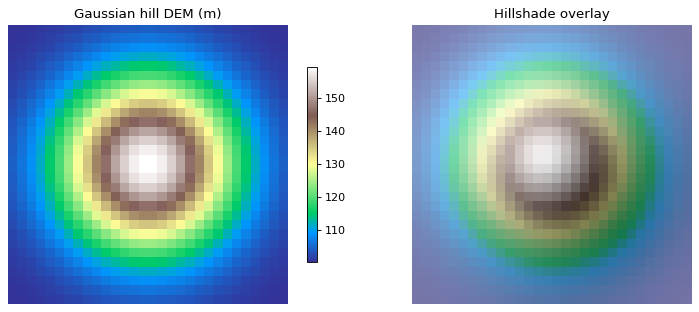

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

ls = LightSource(azdeg=315, altdeg=45)
shade = ls.hillshade(z, vert_exag=2.0, dx=10.0, dy=10.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].imshow(z, cmap="terrain", origin="upper")
axes[0].set_title("Gaussian hill DEM (m)"); axes[0].axis("off")
fig.colorbar(im, ax=axes[0], shrink=0.7)
axes[1].imshow(shade, cmap="gray", origin="upper")
axes[1].imshow(z, cmap="terrain", origin="upper", alpha=0.5)
axes[1].set_title("Hillshade overlay"); axes[1].axis("off")
fig.tight_layout()
plt.show()


## W-21 — Topographic Position Index

TPI = z - focal_mean(z). Positive at ridges, negative in valleys.

In [4]:
tpi = dem.tpi(window=5).read_array()
centre = (15, 15)
print(f"TPI at hill summit:   {tpi[centre]:+.3f}")
print(f"TPI at corner:        {tpi[0, 0]:+.3f}")
print(f"TPI range:            [{tpi.min():+.3f}, {tpi.max():+.3f}]")

TPI at hill summit:   +2.866
TPI at corner:        -0.266
TPI range:            [-1.414, +2.866]


## W-22 — Deviation from mean elevation (standardised TPI)

(z − focal_mean) / focal_sd. Dimensionless ridge/valley index — comparable across regimes with
very different relief.

In [5]:
dev = dem.deviation_from_mean(window=5).read_array()
print(f"Deviation at summit:  {dev[centre]:+.3f}")
print(f"Deviation range:      [{dev.min():+.3f}, {dev.max():+.3f}]")

Deviation at summit:  +1.320
Deviation range:      [-1.224, +1.320]


## W-23 — Standard deviation of elevation

Focal-window SD as a roughness proxy. Largest on the hill flanks where the surface bends most
rapidly.

In [6]:
sd = dem.elev_std(window=5).read_array()
valid_sd = sd[sd != -9999.0]
print(f"Elevation SD range:   [{valid_sd.min():.3f}, {valid_sd.max():.3f}] m")
print(f"Mean SD:              {valid_sd.mean():.3f} m")

Elevation SD range:   [0.217, 7.824] m
Mean SD:              4.224 m


## W-24 — Ruggedness index (Riley et al. 1999)

Per-cell mean of absolute elevation differences over the 8-neighbour window. Output unit = DEM
elevation unit.

In [7]:
rug = dem.ruggedness(window=3).read_array()
valid_rug = rug[rug != -9999.0]
print(f"Ruggedness range:     [{valid_rug.min():.3f}, {valid_rug.max():.3f}] m")

Ruggedness range:     [0.105, 4.445] m


## Visualise: focal-window indices (W-21..W-24)

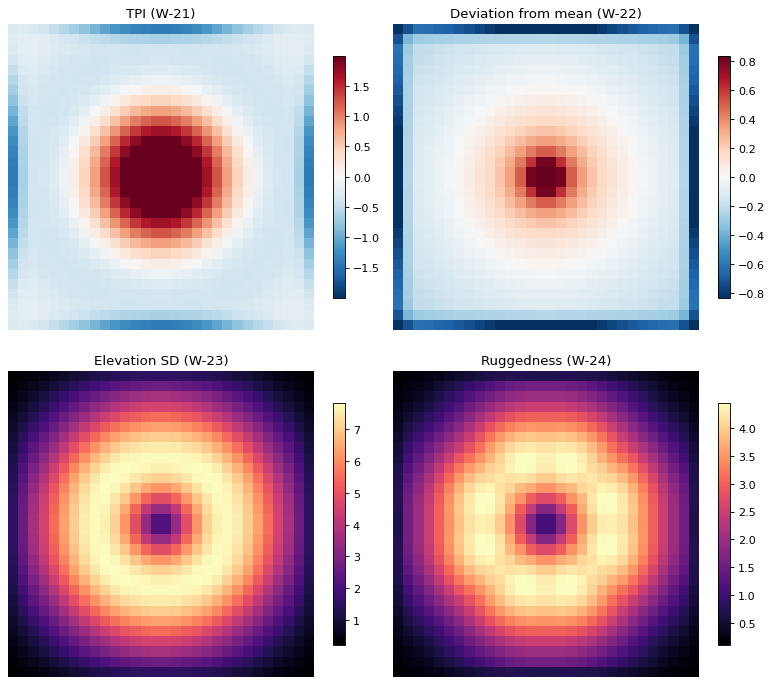

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
no_val = -9999.0

def _mask(a):
    return np.where((a == no_val) | (~np.isfinite(a)), np.nan, a)

vlim = np.nanpercentile(np.abs(_mask(tpi)), 95)
im = axes[0, 0].imshow(_mask(tpi), cmap="RdBu_r", vmin=-vlim, vmax=vlim, origin="upper")
axes[0, 0].set_title("TPI (W-21)"); axes[0, 0].axis("off")
fig.colorbar(im, ax=axes[0, 0], shrink=0.7)

vlim = np.nanpercentile(np.abs(_mask(dev)), 95)
im = axes[0, 1].imshow(_mask(dev), cmap="RdBu_r", vmin=-vlim, vmax=vlim, origin="upper")
axes[0, 1].set_title("Deviation from mean (W-22)"); axes[0, 1].axis("off")
fig.colorbar(im, ax=axes[0, 1], shrink=0.7)

im = axes[1, 0].imshow(_mask(sd), cmap="magma", origin="upper")
axes[1, 0].set_title("Elevation SD (W-23)"); axes[1, 0].axis("off")
fig.colorbar(im, ax=axes[1, 0], shrink=0.7)

im = axes[1, 1].imshow(_mask(rug), cmap="magma", origin="upper")
axes[1, 1].set_title("Ruggedness (W-24)"); axes[1, 1].axis("off")
fig.colorbar(im, ax=axes[1, 1], shrink=0.7)
fig.tight_layout()
plt.show()


## W-25 — Curvature family

Zevenbergen-Thorne 1987 polynomial fit on a 3×3 stencil. Five variants share one kernel.

In [9]:
for kind in ("plan", "profile", "total", "mean", "gaussian"):
    arr = dem.curvature(kind=kind).read_array()
    finite = arr[arr != -9999.0]
    print(f"  {kind:9s}  range=[{finite.min():+.4f}, {finite.max():+.4f}]  shape={arr.shape}")

# Sanity: mean = total / 2 on the interior
total = dem.curvature(kind="total").read_array()
mean = dem.curvature(kind="mean").read_array()
np.testing.assert_allclose(mean[2:-2, 2:-2], total[2:-2, 2:-2] / 2.0, atol=1e-5)
print("\nIdentity mean == total / 2 holds (interior).")

  plan       range=[-0.0033, +0.0148]  shape=(30, 30)
  profile    range=[-0.0146, +0.0180]  shape=(30, 30)
  total      range=[-0.0294, +0.0170]  shape=(30, 30)
  mean       range=[-0.0147, +0.0085]  shape=(30, 30)
  gaussian   range=[-0.0000, +0.0002]  shape=(30, 30)

Identity mean == total / 2 holds (interior).


## Visualise: curvature family + normal-vector deviation

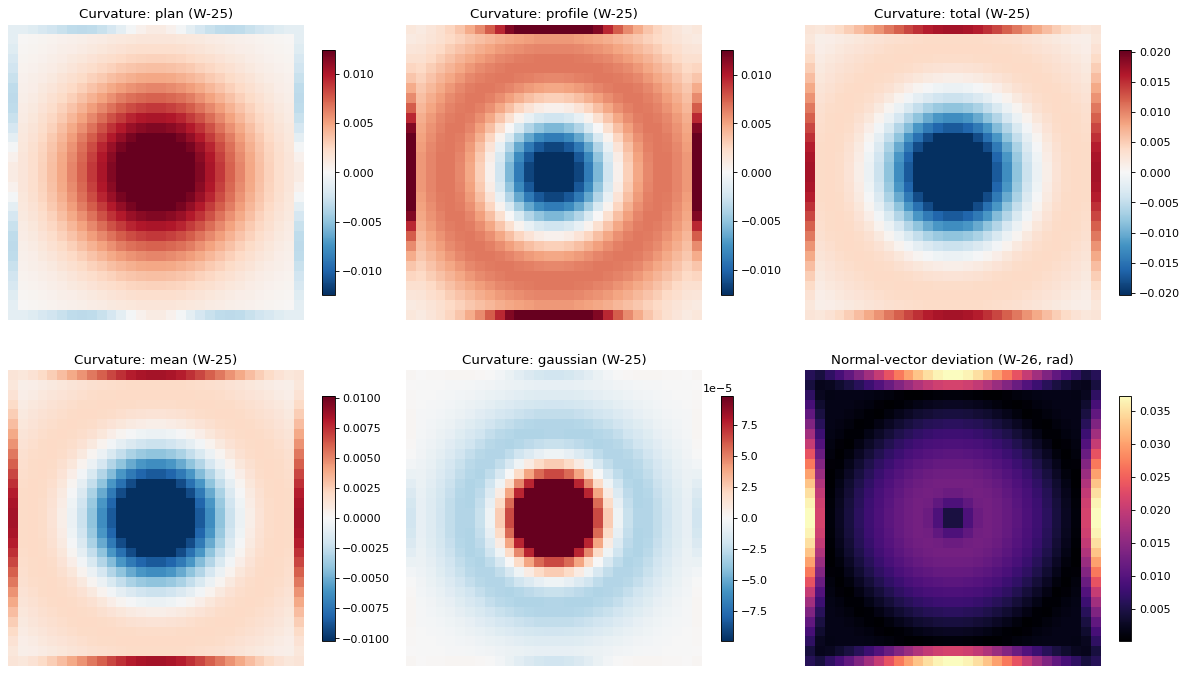

In [10]:
import matplotlib.pyplot as plt

def _mask(a):
    return np.where((a == -9999.0) | (~np.isfinite(a)), np.nan, a)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, kind in zip(axes.flat[:5], ("plan", "profile", "total", "mean", "gaussian")):
    arr = _mask(dem.curvature(kind=kind).read_array())
    vlim = np.nanpercentile(np.abs(arr), 95)
    im = ax.imshow(arr, cmap="RdBu_r", vmin=-vlim, vmax=vlim, origin="upper")
    ax.set_title(f"Curvature: {kind} (W-25)"); ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.7)

# 6th panel: normal-vector angular deviation
nvd_arr = dem.normal_vector_deviation(window=3).read_array()
im = axes.flat[5].imshow(_mask(nvd_arr), cmap="magma", origin="upper")
axes.flat[5].set_title("Normal-vector deviation (W-26, rad)"); axes.flat[5].axis("off")
fig.colorbar(im, ax=axes.flat[5], shrink=0.7)
fig.tight_layout()
plt.show()


## W-26 — Normal-vector angular deviation

Per-cell angle between the local surface normal and the focal-mean normal. Output in radians.

In [11]:
nvd = dem.normal_vector_deviation(window=3).read_array()
valid_nvd = nvd[nvd != -9999.0]
print(f"Normal deviation range: [{valid_nvd.min():.4f}, {valid_nvd.max():.4f}] rad")
print(f"Equivalent in degrees:  [{np.rad2deg(valid_nvd.min()):.3f}, {np.rad2deg(valid_nvd.max()):.3f}]°")

Normal deviation range: [0.0001, 0.0373] rad
Equivalent in degrees:  [0.008, 2.136]°


## W-27 — Topographic openness

Yokoyama 2002. Positive openness: how exposed each cell is to the sky (large = ridge / hilltop).
Negative openness: how deeply each cell is enclosed by surroundings (large = pit / valley floor).

In [12]:
pos = dem.openness(search_radius=5, kind="positive").read_array()
neg = dem.openness(search_radius=5, kind="negative").read_array()
print(f"Positive openness at summit: {pos[centre]:.4f} rad")
print(f"Positive openness at corner: {pos[0, 0]:.4f} rad")
print(f"Negative openness at summit: {neg[centre]:.4f} rad")
print(f"Negative openness range:     [{neg.min():.4f}, {neg.max():.4f}] rad")

Positive openness at summit: 1.5708 rad
Positive openness at corner: 1.5548 rad
Negative openness at summit: 1.2313 rad
Negative openness range:     [1.2313, 1.5708] rad


## W-28 — Sky-view factor

Fraction of the upper hemisphere visible from each cell. Range [0, 1]; 1 on flat terrain;
< 1 wherever surrounding terrain occludes part of the sky.

In [13]:
svf = dem.sky_view_factor(search_radius=5).read_array()
valid_svf = svf[svf != -9999.0]
print(f"SVF range:        [{valid_svf.min():.4f}, {valid_svf.max():.4f}]")
print(f"SVF at summit:    {svf[centre]:.4f}")
print(f"SVF at corner:    {svf[0, 0]:.4f}")

assert (valid_svf >= 0).all() and (valid_svf <= 1.0 + 1e-6).all()

SVF range:        [0.8417, 1.0000]
SVF at summit:    1.0000
SVF at corner:    0.9840


## Visualise: openness + sky-view factor (W-27, W-28)

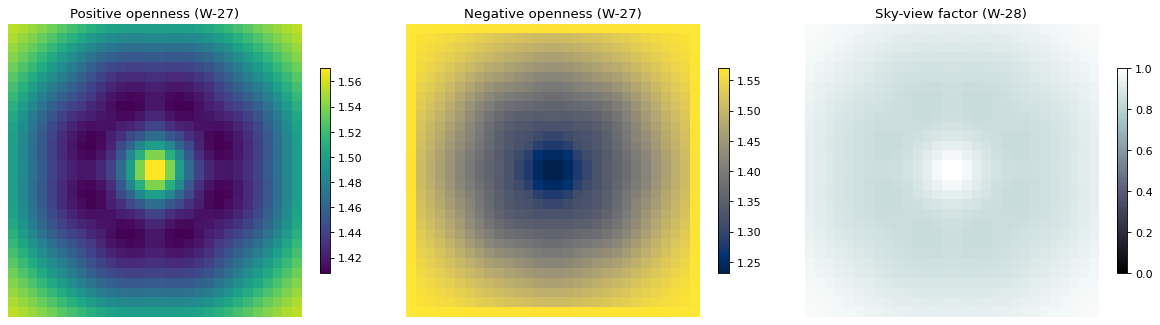

In [14]:
import matplotlib.pyplot as plt

def _mask(a):
    return np.where(a == -9999.0, np.nan, a)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im = axes[0].imshow(_mask(pos), cmap="viridis", origin="upper")
axes[0].set_title("Positive openness (W-27)"); axes[0].axis("off")
fig.colorbar(im, ax=axes[0], shrink=0.7)

im = axes[1].imshow(_mask(neg), cmap="cividis", origin="upper")
axes[1].set_title("Negative openness (W-27)"); axes[1].axis("off")
fig.colorbar(im, ax=axes[1], shrink=0.7)

im = axes[2].imshow(_mask(svf), cmap="bone", vmin=0, vmax=1, origin="upper")
axes[2].set_title("Sky-view factor (W-28)"); axes[2].axis("off")
fig.colorbar(im, ax=axes[2], shrink=0.7)
fig.tight_layout()
plt.show()


## Summary

Eight terrain-attribute rasters from one DEM in eight calls. Each surface respects the DEM's
no-data sentinel, returns float32 storage, and aligns with the source geotransform.